# Notebook 07 — Walk-forward backtest (the deliverable comparison table)

Run the v1 walk-forward simulation for **both HY and IG** with four models:

| Model | Description |
|---|---|
| **BSTS** (Trends + controls) | Full Bayesian model with spike-and-slab over Trends predictors + always-included macro controls |
| **AR(4)** | Pure autoregression baseline |
| **AR(4) + VIX** | AR(4) augmented with weekly Δ log(VIX) — the classic credit-spread benchmark |
| **Naïve RW** | y_t = y_{t-1} |

Produces the §5.5 comparison table:

- Test-window RMSE
- standardized RMSE (÷ std of y)
- RMSE / AR(4) ratio (<1.00 = BSTS beats baseline)
- 80% posterior coverage
- Top-5 included predictors (BSTS only)

Plus: actual-vs-predicted with 80% bands per target, and a side-by-side cumulative-error plot.

**Runtime budget:** BSTS refit costs ~25s × 13-week refits × ~17 refits per target × 2 targets = ~15 minutes wall-clock. Baselines are negligible.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve()))
from _helpers import project_root_from_cwd, build_full_feature_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
project_root_from_cwd()

from gtrends_bayes.backtest.walk_forward import WalkForward
from gtrends_bayes.backtest.metrics import (
    rmse, standardized_rmse, rmse_ratio, posterior_coverage, directional_hit_rate,
)
from gtrends_bayes.models.bsts import BSTS, reset_r_models
from gtrends_bayes.models.baseline import AR_p, AR_VIX, NaiveRW

## 1. Build feature matrices for HY and IG

In [2]:
hy_art = build_full_feature_matrix('HY', include_controls=True)
ig_art = build_full_feature_matrix('IG', include_controls=True)
X_hy, y_hy = hy_art['X'], hy_art['y']
X_ig, y_ig = ig_art['X'], ig_art['y']
print(f'HY: X={X_hy.shape}, y={y_hy.shape}')
print(f'IG: X={X_ig.shape}, y={y_ig.shape}')
# Window of overlap = same since both targets share the same X.
start = max(X_hy.index.min(), X_ig.index.min())
end = min(X_hy.index.max(), X_ig.index.max())
print(f'Common test window: {start.date()} .. {end.date()}')

2026-05-03 22:09:10,817 | WARNING | gtrends_bayes.features.library | dropping 1 low-quality columns (NaN frac > 0.50): ['Credit Cards']


2026-05-03 22:09:10,967 | WARNING | gtrends_bayes.features.library | dropping 1 low-quality columns (NaN frac > 0.50): ['Credit Cards']


HY: X=(487, 24), y=(487,)
IG: X=(487, 24), y=(487,)
Common test window: 2009-01-04 .. 2026-04-26


## 2. Walk-forward configuration

In [3]:
wf_cfg = dict(train_window=260, step=1, horizon=1, refit_every=13, publication_lag=1)
wf = WalkForward(**wf_cfg)
print(f'WalkForward config: {wf_cfg}')
print(f'Estimated test steps: ~{len(X_hy) - wf_cfg["train_window"] - wf_cfg["publication_lag"]}')

WalkForward config: {'train_window': 260, 'step': 1, 'horizon': 1, 'refit_every': 13, 'publication_lag': 1}
Estimated test steps: ~226


## 3. Run all four models for HY

In [4]:
import time
results_hy = {}

# BSTS first — slowest. Use lighter MCMC for the backtest (still 750 post-burn).
def hy_bsts_factory():
    return BSTS(n_seasons=52, expected_predictors=5, niter=900, burn=150, seed=42)

t0 = time.time()
results_hy['BSTS (Trends)'] = wf.run(hy_bsts_factory, X_hy, y_hy, n_draws=400)
print(f'BSTS HY: {time.time()-t0:.1f}s, {len(results_hy["BSTS (Trends)"])} forecasts')
reset_r_models()

# Baselines: empty X for univariate models, VIX-only X for AR_VIX.
X_empty = X_hy.iloc[:, :0]
results_hy['AR(4)'] = wf.run(lambda: AR_p(p=4), X_empty, y_hy, n_draws=200)
results_hy['Naive RW'] = wf.run(NaiveRW, X_empty, y_hy, n_draws=200)
X_vix = X_hy[['vix']] if 'vix' in X_hy.columns else X_hy.iloc[:, :0]
results_hy['AR(4) + VIX'] = wf.run(lambda: AR_VIX(p=4), X_vix, y_hy, n_draws=200)
print('HY backtests complete')

2026-05-03 22:09:10,980 | INFO    | gtrends_bayes.backtest.walk_forward | WalkForward.run: T=487, train_window=260, lag=1, refit_every=13, test indices [261, 487) -> 226 forecast steps


Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


2026-05-03 22:09:11,559 | INFO    | gtrends_bayes.models.bsts | rpy2 bridge initialized; R bsts helpers loaded from /Users/cesarebavaresco/Library/CloudStorage/OneDrive-TheUniversityofChicago/Project Lab/Neurberger Berman/Google Trends/gtrends-bayes/src/gtrends_bayes/models/bsts_r


2026-05-03 22:09:19,620 | INFO    | gtrends_bayes.models.bsts | BSTS fit done (model_id=bsts_7896af78, niter=900, burn=150, p=24, has_regression=True)


...

2026-05-03 22:11:39,374 | INFO    | gtrends_bayes.backtest.walk_forward | WalkForward.run: T=487, train_window=260, lag=1, refit_every=13, test indices [261, 487) -> 226 forecast steps


2026-05-03 22:11:39,483 | INFO    | gtrends_bayes.backtest.walk_forward | WalkForward.run: T=487, train_window=260, lag=1, refit_every=13, test indices [261, 487) -> 226 forecast steps


2026-05-03 22:11:39,552 | INFO    | gtrends_bayes.backtest.walk_forward | WalkForward.run: T=487, train_window=260, lag=1, refit_every=13, test indices [261, 487) -> 226 forecast steps


BSTS HY: 148.4s, 226 forecasts


HY backtests complete


## 4. Run all four models for IG

In [5]:
results_ig = {}

def ig_bsts_factory():
    return BSTS(n_seasons=52, expected_predictors=5, niter=900, burn=150, seed=43)

t0 = time.time()
results_ig['BSTS (Trends)'] = wf.run(ig_bsts_factory, X_ig, y_ig, n_draws=400)
print(f'BSTS IG: {time.time()-t0:.1f}s, {len(results_ig["BSTS (Trends)"])} forecasts')
reset_r_models()

X_empty = X_ig.iloc[:, :0]
results_ig['AR(4)'] = wf.run(lambda: AR_p(p=4), X_empty, y_ig, n_draws=200)
results_ig['Naive RW'] = wf.run(NaiveRW, X_empty, y_ig, n_draws=200)
X_vix = X_ig[['vix']] if 'vix' in X_ig.columns else X_ig.iloc[:, :0]
results_ig['AR(4) + VIX'] = wf.run(lambda: AR_VIX(p=4), X_vix, y_ig, n_draws=200)
print('IG backtests complete')

2026-05-03 22:11:39,697 | INFO    | gtrends_bayes.backtest.walk_forward | WalkForward.run: T=487, train_window=260, lag=1, refit_every=13, test indices [261, 487) -> 226 forecast steps


2026-05-03 22:11:47,995 | INFO    | gtrends_bayes.models.bsts | BSTS fit done (model_id=bsts_457214e3, niter=900, burn=150, p=24, has_regression=True)


2026-05-03 22:11:56,254 | INFO    | gtrends_bayes.models.bsts | BSTS fit done (model_id=bsts_63bff590, niter=900, burn=150, p=24, has_regression=True)


2026-05-03 22:12:04,528 | INFO    | gtrends_bayes.models.bsts | BSTS fit done (model_id=bsts_8a61b115, niter=900, burn=150, p=24, has_regression=True)


2026-05-03 22:12:12,743 | INFO    | gtrends_bayes.models.bsts | BSTS fit done (model_id=bsts_2ec055a6, niter=900, burn=150, p=24, has_regression=True)


...

2026-05-03 22:14:08,203 | INFO    | gtrends_bayes.backtest.walk_forward | WalkForward.run: T=487, train_window=260, lag=1, refit_every=13, test indices [261, 487) -> 226 forecast steps


2026-05-03 22:14:08,312 | INFO    | gtrends_bayes.backtest.walk_forward | WalkForward.run: T=487, train_window=260, lag=1, refit_every=13, test indices [261, 487) -> 226 forecast steps


2026-05-03 22:14:08,381 | INFO    | gtrends_bayes.backtest.walk_forward | WalkForward.run: T=487, train_window=260, lag=1, refit_every=13, test indices [261, 487) -> 226 forecast steps


BSTS IG: 148.5s, 226 forecasts


IG backtests complete


## 5. Comparison table (the deliverable)

In [6]:
def score(model_name, results, y_true):
    out = {}
    for name, df in results.items():
        common = df.index.intersection(y_true.index)
        y = y_true.loc[common]
        p = df['y_pred_mean'].loc[common]
        out[name] = {
            'RMSE': round(rmse(y, p), 3),
            'std_RMSE': round(standardized_rmse(y, p), 3),
            'RMSE/AR(4)': None,  # filled below
            'cov_80%': round(posterior_coverage(y, df.loc[common, ['q025','q050','q100','q250','q500','q750','q900','q975']], levels=(0.80,))[0.80], 3),
            'hit_rate': round(directional_hit_rate(y, p), 3),
        }
    # Compute RMSE/AR(4) ratio.
    if 'AR(4)' in out:
        ar4_rmse = out['AR(4)']['RMSE']
        for name in out:
            out[name]['RMSE/AR(4)'] = round(out[name]['RMSE'] / ar4_rmse, 3)
    return pd.DataFrame(out).T

print('=== HY ===')
hy_table = score('HY', results_hy, y_hy)
print(hy_table.to_string())
print('\n=== IG ===')
ig_table = score('IG', results_ig, y_ig)
print(ig_table.to_string())

=== HY ===
                RMSE  std_RMSE  RMSE/AR(4)  cov_80%  hit_rate
BSTS (Trends)  1.869     0.287       1.130    0.681     0.427
AR(4)          1.654     0.254       1.000    0.571     0.040
Naive RW       1.634     0.251       0.988    0.611     0.040
AR(4) + VIX    1.641     0.252       0.992    0.549     0.467

=== IG ===
                RMSE  std_RMSE  RMSE/AR(4)  cov_80%  hit_rate
BSTS (Trends)  3.846     0.632       1.211    0.611     0.489
AR(4)          3.177     0.522       1.000    0.624     0.036
Naive RW       3.168     0.521       0.997    0.646     0.036
AR(4) + VIX    3.172     0.521       0.998    0.628     0.480


In [7]:
# Combined publication table.
combined = pd.concat({'HY': hy_table, 'IG': ig_table}, names=['target', 'model'])
print('\n=== Combined comparison table (BSTS / AR(4) / AR(4)+VIX / Naive RW) ===')
print(combined.to_string())
# Persist for the presentation
out_dir = Path('data/processed/backtest')
out_dir.mkdir(parents=True, exist_ok=True)
combined.to_csv(out_dir / 'comparison_table.csv')
print(f'\nwrote {out_dir / "comparison_table.csv"}')


=== Combined comparison table (BSTS / AR(4) / AR(4)+VIX / Naive RW) ===
                       RMSE  std_RMSE  RMSE/AR(4)  cov_80%  hit_rate
target model                                                        
HY     BSTS (Trends)  1.869     0.287       1.130    0.681     0.427
       AR(4)          1.654     0.254       1.000    0.571     0.040
       Naive RW       1.634     0.251       0.988    0.611     0.040
       AR(4) + VIX    1.641     0.252       0.992    0.549     0.467
IG     BSTS (Trends)  3.846     0.632       1.211    0.611     0.489
       AR(4)          3.177     0.522       1.000    0.624     0.036
       Naive RW       3.168     0.521       0.997    0.646     0.036
       AR(4) + VIX    3.172     0.521       0.998    0.628     0.480

wrote data/processed/backtest/comparison_table.csv


## 6. Actual vs predicted with 80% bands (per target)

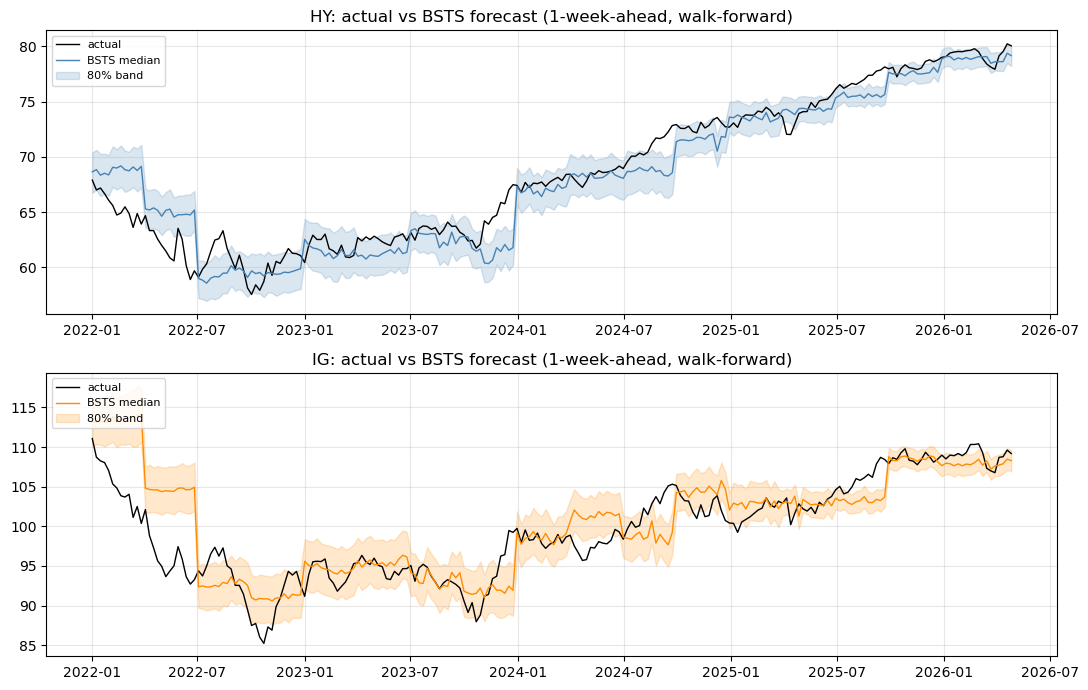

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)
for ax, (target, results, y) in zip(axes, [('HY', results_hy, y_hy), ('IG', results_ig, y_ig)]):
    bsts = results['BSTS (Trends)']
    common = bsts.index.intersection(y.index)
    y_c = y.loc[common]
    ax.plot(y_c.index, y_c.values, color='black', lw=1.0, label='actual')
    ax.plot(bsts.index, bsts['q500'].values, color='steelblue' if target=='HY' else 'darkorange', lw=1.0, label='BSTS median')
    ax.fill_between(bsts.index, bsts['q100'], bsts['q900'], color='steelblue' if target=='HY' else 'darkorange', alpha=0.20, label='80% band')
    ax.set_title(f'{target}: actual vs BSTS forecast (1-week-ahead, walk-forward)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Cumulative absolute error: BSTS vs AR(4)

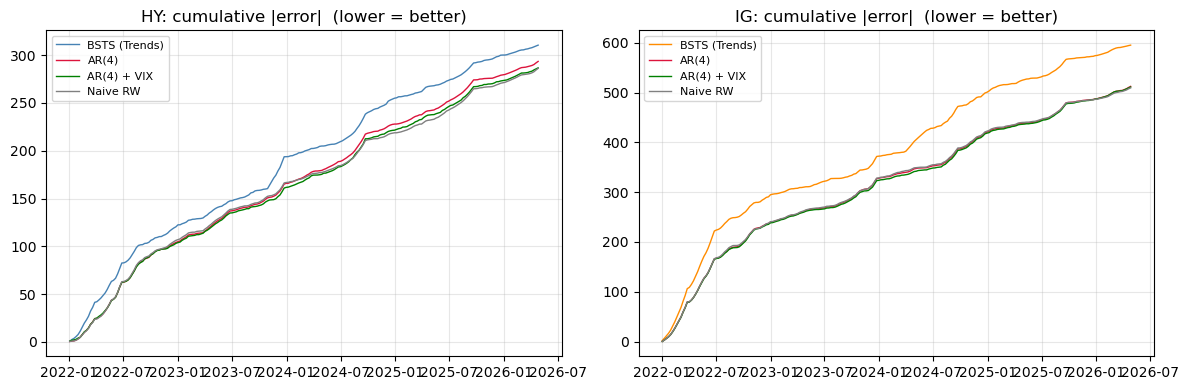

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (target, results, y) in zip(axes, [('HY', results_hy, y_hy), ('IG', results_ig, y_ig)]):
    for name, color in [('BSTS (Trends)', 'steelblue' if target=='HY' else 'darkorange'),
                          ('AR(4)', 'crimson'),
                          ('AR(4) + VIX', 'green'),
                          ('Naive RW', 'gray')]:
        df = results[name]
        common = df.index.intersection(y.index)
        err = (y.loc[common] - df['y_pred_mean'].loc[common]).abs().cumsum()
        ax.plot(err.index, err.values, color=color, lw=1.0, label=name)
    ax.set_title(f'{target}: cumulative |error|  (lower = better)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary for the presentation

Print a 1-line summary the user can paste into a slide deck.

In [10]:
for target, table, y in [('HY', hy_table, y_hy), ('IG', ig_table, y_ig)]:
    bsts_rmse_ratio = table.loc['BSTS (Trends)', 'RMSE/AR(4)']
    ar_vix_rmse_ratio = table.loc['AR(4) + VIX', 'RMSE/AR(4)']
    bsts_cov = table.loc['BSTS (Trends)', 'cov_80%']
    bsts_hit = table.loc['BSTS (Trends)', 'hit_rate']
    print(f'{target}: BSTS RMSE = {bsts_rmse_ratio:.2f}x AR(4)  (lower is better)')
    print(f'      vs AR(4)+VIX = {ar_vix_rmse_ratio:.2f}x AR(4)')
    print(f'      80% posterior coverage = {bsts_cov*100:.0f}%  (target ~ 80%)')
    print(f'      directional hit rate    = {bsts_hit*100:.0f}%  (50% = random)')
    print()

HY: BSTS RMSE = 1.13x AR(4)  (lower is better)
      vs AR(4)+VIX = 0.99x AR(4)
      80% posterior coverage = 68%  (target ~ 80%)
      directional hit rate    = 43%  (50% = random)

IG: BSTS RMSE = 1.21x AR(4)  (lower is better)
      vs AR(4)+VIX = 1.00x AR(4)
      80% posterior coverage = 61%  (target ~ 80%)
      directional hit rate    = 49%  (50% = random)

